Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Базовый F1-Score: 0.7294
Базовый Precision-Recall AUC: 0.7802


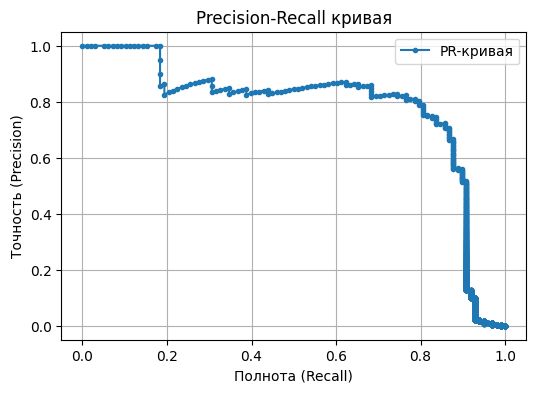

In [16]:
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

drive.mount('/content/drive')
path = "/content/drive/MyDrive/creditcard.csv"
df = pd.read_csv(path)
df.head()
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=11, stratify=y)

scaler = StandardScaler()
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

model_base = LogisticRegression(random_state=52,max_iter=1000)
model_base.fit(X_train, y_train)

y_pred = model_base.predict(X_test)
y_proba = model_base.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

print(f"Базовый F1-Score: {f1:.4f}")
print(f"Базовый Precision-Recall AUC: {pr_auc:.4f}")
plt.figure(figsize=(6,4))
plt.plot(recall, precision, marker='.', label='PR-кривая')
plt.xlabel('Полнота (Recall)')
plt.ylabel('Точность (Precision)')
plt.title('Precision-Recall кривая')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

results = {}

model_weighted = LogisticRegression(random_state=52, max_iter=1000, class_weight="balanced")
model_weighted.fit(X_train, y_train)

y_weight_pred = model_weighted.predict(X_test)
y_weight_proba = model_weighted.predict_proba(X_test)[:,1]

precision_w, recall_w, _ = precision_recall_curve(y_test, y_weight_proba)
results['Class Weighting'] = {
    'F1-Score': f1_score(y_test, y_weight_pred),
    'Precision-Recall AUC' : auc(recall_w, precision_w)
}

smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, y_train)

model_smote = LogisticRegression(random_state=52, max_iter=1000)
model_smote.fit(X_train_smote, Y_train_smote)

y_smote_pred = model_smote.predict(X_test)
y_smote_proba = model_smote.predict_proba(X_test)[:,1]

precision_smote, recall_smote, _ = precision_recall_curve(y_test, y_smote_proba)
results['SMOTE'] = {
    'F1-Score' : f1_score(y_test, y_smote_pred),
    'Precision-Recall AUC' : auc(recall_smote, precision_smote)
}

random_under_sampler = RandomUnderSampler(random_state=52)
X_undersampling_train, y_undersampling_train = random_under_sampler.fit_resample(X_train, y_train)

model_undersampling = LogisticRegression(random_state=52, max_iter=1000)
model_undersampling.fit(X_undersampling_train, y_undersampling_train)

y_undersampling_pred = model_undersampling.predict(X_test)
y_undersampling_proba = model_undersampling.predict_proba(X_test)[:,1]

precision_undersampling, recall_undersampling, _ = precision_recall_curve(y_test, y_undersampling_proba)
results['RandomUnderSampling'] = {
    'F1-Score' : f1_score(y_test, y_undersampling_pred),
    'Precision-Recall AUC' : auc(recall_undersampling, precision_undersampling)
}

comparison_df = pd.DataFrame(results).T
print(comparison_df)



                     F1-Score  Precision-Recall AUC
Class Weighting      0.123269              0.759503
SMOTE                0.113402              0.761363
RandomUnderSampling  0.069903              0.548365


In [13]:
weights = [1, 2, 3, 5, 10, 20, 30, 50, 100]

for w in weights:
    model = LogisticRegression(class_weight={0: 1, 1: w}, random_state=42, max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(rec_curve, prec_curve)

    print(f"weight={w} | F1={f1:.4f} | PR-AUC={pr_auc:.4f}")

weight=1 | F1=0.7294 | PR-AUC=0.7802
weight=2 | F1=0.7956 | PR-AUC=0.7809
weight=3 | F1=0.7958 | PR-AUC=0.7762
weight=5 | F1=0.7980 | PR-AUC=0.7755
weight=10 | F1=0.8020 | PR-AUC=0.7689
weight=20 | F1=0.7793 | PR-AUC=0.7621
weight=30 | F1=0.7179 | PR-AUC=0.7572
weight=50 | F1=0.6056 | PR-AUC=0.7511
weight=100 | F1=0.3964 | PR-AUC=0.7362


In [14]:
ratios = [200,125,100,50,25,16,12,10,5,3]

print("SMOTE")
for r in ratios:
    smote = SMOTE(sampling_strategy=1/r, random_state=42)
    X_sm, y_sm = smote.fit_resample(X_train, y_train)
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_sm, y_sm)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(rec, prec)

    print(f"Соотношение 1:{r} | F1={f1:.4f} | PR-AUC={pr_auc:.4f}")

print("\nRandomUnderSampler")
for r in ratios:
    rus = RandomUnderSampler(sampling_strategy=1/r, random_state=42)
    X_un, y_un = rus.fit_resample(X_train, y_train)
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_un, y_un)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(rec, prec)

    print(f"Соотношение 1:{r} | F1={f1:.4f} | PR-AUC={pr_auc:.4f}")


SMOTE
Соотношение 1:200 | F1=0.7872 | PR-AUC=0.7744
Соотношение 1:125 | F1=0.8020 | PR-AUC=0.7729
Соотношение 1:100 | F1=0.7980 | PR-AUC=0.7686
Соотношение 1:50 | F1=0.7960 | PR-AUC=0.7631
Соотношение 1:25 | F1=0.7721 | PR-AUC=0.7588
Соотношение 1:16 | F1=0.6911 | PR-AUC=0.7546
Соотношение 1:12 | F1=0.6056 | PR-AUC=0.7535
Соотношение 1:10 | F1=0.5443 | PR-AUC=0.7508
Соотношение 1:5 | F1=0.3492 | PR-AUC=0.7368
Соотношение 1:3 | F1=0.2613 | PR-AUC=0.7390

RandomUnderSampler
Соотношение 1:200 | F1=0.7853 | PR-AUC=0.7661
Соотношение 1:125 | F1=0.7900 | PR-AUC=0.7669
Соотношение 1:100 | F1=0.7861 | PR-AUC=0.7644
Соотношение 1:50 | F1=0.7902 | PR-AUC=0.7623
Соотношение 1:25 | F1=0.6942 | PR-AUC=0.7455
Соотношение 1:16 | F1=0.5535 | PR-AUC=0.7626
Соотношение 1:12 | F1=0.4588 | PR-AUC=0.7488
Соотношение 1:10 | F1=0.4289 | PR-AUC=0.7491
Соотношение 1:5 | F1=0.2848 | PR-AUC=0.7205
Соотношение 1:3 | F1=0.1954 | PR-AUC=0.6852


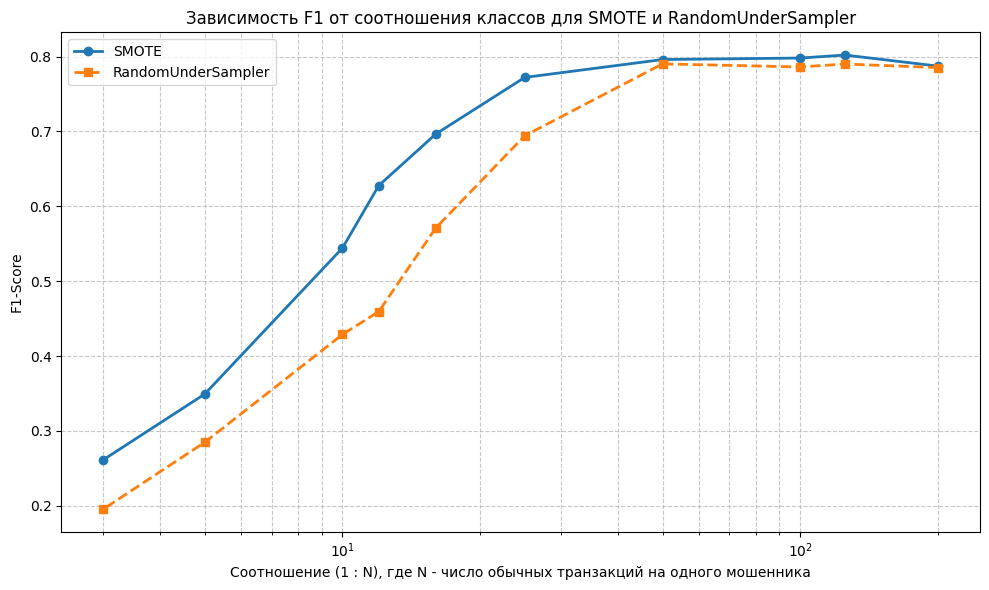

In [15]:
# Данные для SMOTE (соотношения и соответствующие F1)
smote_N = [200, 125, 100, 50, 25, 16, 12, 10, 5, 3]
smote_f1 = [0.7872, 0.8020, 0.7980, 0.7960, 0.7721, 0.6967, 0.6277, 0.5443, 0.3492, 0.2613]

# Данные для RandomUnderSampler
under_N = [200, 125, 100, 50, 25, 16, 12, 10, 5, 3]
under_f1 = [0.7853, 0.7900, 0.7861, 0.7902, 0.6942, 0.5714, 0.4595, 0.4289, 0.2848, 0.1954]

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(smote_N, smote_f1, marker='o', linestyle='-', linewidth=2, label='SMOTE')
plt.plot(under_N, under_f1, marker='s', linestyle='--', linewidth=2, label='RandomUnderSampler')

# Настройка осей (логарифмическая шкала по X, чтобы лучше видеть детали при больших N)
plt.xscale('log')
plt.xlabel('Соотношение (1 : N), где N - число обычных транзакций на одного мошенника')
plt.ylabel('F1-Score')
plt.title('Зависимость F1 от соотношения классов для SMOTE и RandomUnderSampler')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

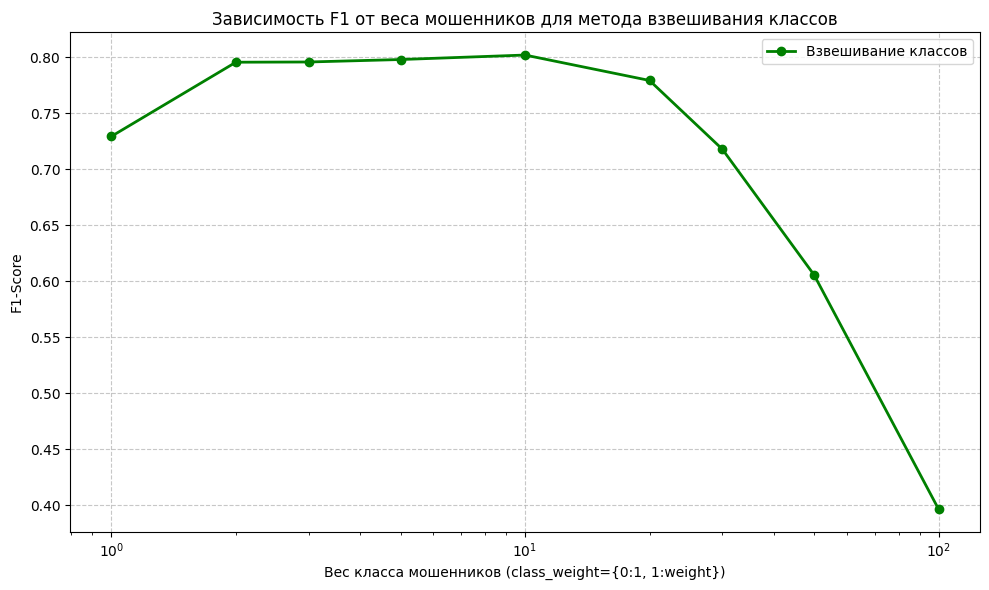

In [ ]:
weights = [1, 2, 3, 5, 10, 20, 30, 50, 100]
f1_scores = [0.7294, 0.7956, 0.7958, 0.7980, 0.8020, 0.7793, 0.7179, 0.6056, 0.3964]

plt.figure(figsize=(10, 6))
plt.plot(weights, f1_scores, marker='o', linestyle='-', linewidth=2, color='green', label='Взвешивание классов')
plt.xscale('log')  # логарифмическая шкала, чтобы лучше видеть детали при малых весах
plt.xlabel('Вес класса мошенников (class_weight={0:1, 1:weight})')
plt.ylabel('F1-Score')
plt.title('Зависимость F1 от веса мошенников для метода взвешивания классов')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('f1_vs_weight.png', dpi=300)
plt.show()